# Cold Rolling &mdash; 316L plane-strain compression

EBSD &rarr; Kanapy &rarr; MiMeDO &rarr; DAMASK &rarr; post-processing, built entirely from the
shared nodes in `functions/nodes.py`. See the project guide
(`index.ipynb`) for what the nodes do and how the
`Keys/<key>/` folders are named.

**This case.** A 316L EBSD map (`ebsd_316L_500x500.ang`) is reconstructed into a
synthetic 3D RVE carrying the real EBSD-derived texture, exported as a MiMeDO
object, then cold-rolled: a single 30 % compressive-strain-in-X plane-strain
step, chosen to drive a large, clearly resolvable microstructure change so
segmentation has something meaningful to detect. The deformed structure is
re-segmented and grain-tracked to capture the evolution.

Pipeline: `load_ebsd_map -> get_stats -> generate_rve -> write_data ->
load_to_damask -> run_damask -> post_processing` (one linear branch).

**Before running.** `write_data` requires the updated Kanapy build (the
`write_data` / `microstructure_state_id` / `orientation_identifier` schema,
and `create_microstructure_identifier` now living in Kanapy's `api.py`).
Use the `damask` conda environment.

**Cost.** `run_damask` actually launches `DAMASK_grid` and takes real compute
time to finish -- unlike the earlier steps, which run in seconds. The results
of the last completed run are already on disk under `Keys/`.

*Still to come: a multi-branch macro (multiple loading cases sharing one RVE).*


In [1]:
import logging
logging.disable(logging.WARNING)

import sys
import orix
from pathlib import Path

# Make the shared `functions` package importable.
# This notebook lives at <repo>/cases/<case>, so parents[1] is the repo root,
# so three parents up is the package's containing folder.
sys.path.insert(0, str(Path.cwd().parents[1]))

from pyiron_workflow import Workflow
from functions.nodes import (
    load_ebsd_map, get_stats, generate_rve, write_data, load_to_damask, run_damask,
    post_processing,
)


In [2]:
# ============================================
# Microstructure / RVE descriptor
# ============================================
nvox =  20                   # Number of voxels in each Cartesian direction (Nx = Ny = Nz = nvox -> cubic RVE)
lside = 20                  # Side length of the RVE in um in each direction
periodic_RVE = True         # Generate a periodic RVE in Kanapy

# --- Grain-size cutoffs: deliberately truncating the real measured distribution ---
# The EBSD map's measured grain population has a median equivalent diameter
# of ~41.3 um (see the "Median values: equiv. diameter" line printed during
# EBSD loading). A physically-representative RVE at that grain size would
# need a box of roughly 250-300 um per side -- too expensive for our target
# model size (<=50 um, preferably <=30 um).
#
# deq_max_RVE truncates the sampled grain-size distribution to fit the
# target box. With deq_max_RVE=14.0 um, we are deliberately sampling only
# the finer fraction of this material's real grain population (roughly the
# smallest ~5-10% of grains, based on the fitted lognormal shape) -- this
# is NOT a scaled-down version of the whole material's grain size. Keep
# this caveat recorded in the MiMeDO metadata/description once write_data
# is wired back in, so anyone using this RVE later knows it targets the
# fine-grain fraction for computational tractability, not the material's
# overall grain size.
deq_max_RVE = 12.0

# deq_min_RVE keeps the smallest sampled grains from getting too close to
# the voxel resolution (voxel size = lside / nvox = 30/30 = 1.0 um here).
# Left unset, Kanapy's own default is 1.3*loc = 0.0 (loc is always 0 for
# EBSD-derived stats), which would let a grain be sampled with almost no
# lower bound -- and a grain only 1-2 voxels across voxelizes badly.
# 6.0 um keeps at least ~6 voxels across even the smallest grain at this
# resolution; adjust together with nvox/lside if either changes.
deq_min_RVE = 6.0

ebsd_file = "ebsd_316L_500x500.ang"


In [3]:
# ============================================
# MiMeDO metadata, boundary condition, phases, units
# (needed by write_data; a single placeholder cold-rolling-in-X case for now --
# the X/Y/Z macro comes back once we standardize the DAMASK-side nodes too)
# ============================================
user_metadata = {
    "$schema": "https://github.com/Ronakshoghi/MetadataSchema/blob/main/microstructure_sensitive_mechanical_metadata_schema.json",
    "title": "Crystal plasticity simulation of 316L microstructural evolution during cold rolling",
    "creator": ["Rezek, Yousef"],
    "creator_ORCID": ["0009-0009-7588-6401"],
    "creator_affiliation": ["Ruhr University Bochum"],
    "creator_institute": ["Interdisciplinary Centre for Advanced Materials Simulation"],
    "creator_group": ["Micromechanical and Macroscopic Modelling"],
    "contributor": ["Hartmaier, Alexander"],
    "contributor_ORCID": ["0000-0002-3710-1169"],
    "contributor_affiliation": ["Ruhr University Bochum"],
    "contributor_institute": ["Interdisciplinary Centre for Advanced Materials Simulation"],
    "contributor_group": ["Micromechanical and Macroscopic Modelling"],
    "date": "",
    "shared_with": [{"access_type": "c"}, {"access_type": "all"}],
    "description": (
        "This data object contains a 3D crystal plasticity plane-strain compression "
        "(cold rolling) simulation of 316L stainless steel performed with an "
        "FFT-based spectral solver using the DAMASK framework. X is the "
        "rolling/compression direction (30% engineering compressive strain "
        "prescribed), Z is the transverse/width direction held at zero strain "
        "(the plane-strain constraint that models confinement between the rolls), "
        "and Y is left stress-free so the material can flow/thicken to conserve "
        "volume, as in real rolling. This drives a large, clearly resolvable "
        "change in the microstructure, so that grain segmentation on the deformed "
        "state has something meaningful to detect. The RVE's grain-size "
        "distribution is truncated (deq_max_RVE, deq_min_RVE) to fit a "
        "computationally tractable box size and represents the fine-grain "
        "fraction of the measured EBSD microstructure, not its overall grain "
        "size -- see the truncation note above deq_max_RVE in the descriptor cell."
    ),
    "rights": "Creative Commons Attribution 4.0 International",
    "rights_holder": ["Ruhr University Bochum"],
    "funder_name": "",
    "fund_identifier": "",
    "publisher": "",
    "relation": [],
    "keywords": ["crystal plasticity", "DAMASK", "Kanapy", "316L", "cold rolling", "plane-strain compression"],
}

boundary_condition = {
    "mechanical_BC": [
        {
            "vertex_list": ["V000", "V001", "V101", "V100", "V010", "V011", "V111", "V110"],
            "loading_type": "strain-stress",
            "loading_mode": "monotonic",
            "applied_load": [
                {
                    # Cold-rolling / plane-strain compression:
                    #   X (xx): prescribed compressive engineering strain -0.3
                    #   Z (zz): fixed at zero strain (plane-strain constraint --
                    #           the rolls confine the width direction)
                    #   Y (yy): stress-free (0.0 in the complementary stress
                    #           tensor below) -- material flows/thickens freely
                    "magnitude": [
                        {
                            "xx": -0.3, "yy": "x", "zz": 0.0,
                            "xy": 0.0, "xz": 0.0, "yz": 0.0,
                        },
                        {
                            "xx": "x", "yy": 0.0, "zz": "x",
                            "xy": "x", "xz": "x", "yz": "x",
                        },
                    ],
                    "duration": 100.0,
                    "step": 1.0,
                }
            ],
        }
    ]
}

# ============================================
# Unit system used
# (must be consistent with DAMASK input)
# ============================================
units = {
    "Stress": "Pa",
    "Strain": 1,
    "Length": "m",
    "Angle": "rad",
    "Temperature": "K",
    "Force": "N",
    "Stiffness": "Pa",
    "Time": "s",
}

# ============================================
# Phase and constitutive model description
# ============================================
phase = [
    {
        "phase_id": 0,
        "phase_name": "Iron",
        "volume_fraction": 1.0,
        "lattice_structure": "fcc",
        "constitutive_model": {
                "$schema": "https://raw.githubusercontent.com/Ronakshoghi/MetadataSchema/main/crystal_plasticity_constitutive_model_metadata_schema.json",
                "elastic_model_name": "hooke",
                "elastic_parameters": {
                    "C11": 106.75e+9,
                    "C12": 60.41e+9,
                    "C44": 28.34e+9
                },
                "plastic_model_name": "phenopowerlaw",
                "plastic_parameters": {
                    "N_sl": [12],
                    "a_sl": [2.25],
                    "atol_xi": 1.0,
                    "dot_gamma_0_sl": [0.001],
                    "h_0_sl-sl": [75.e+6],
                    "h_sl-sl": [1, 1, 1.4, 1.4, 1.4, 1.4, 1.4],
                    "n_sl": [20],
                    "output": ["xi_sl"],
                    "xi_0_sl": [31.e+6],
                    "xi_inf_sl": [63.e+6]
                }
            },
        "orientation": {
            "euler_angles": {
                "Phi1": [],
                "Phi": [],
                "Phi2": [],
            },
            "grain_count": None,
            "orientation_identifier": None,
            "crystal_symmetry_group": "m-3m",
            "software": "orix",
            "software_version": orix.__version__,
        },
    }
]

In [4]:
# ============================================
# DAMASK input-file controls (load_to_damask)
# ============================================
f_out_list = (1, )
f_restart_list = (100,)   # write a restart file every 100 increments
outputs = ("F", "P", "F_p", "F_e", "L_p", "O")   # mechanical fields requested from DAMASK, per phase

# ============================================
# DAMASK run controls (run_damask)
# ============================================
n_threads = 10   # OpenMP threads for DAMASK_grid (single MPI process)

# ============================================
# Post-processing controls (post_processing)
# ============================================
pp_quantities = ("O", "F", "sigma", "epsilon_V^0.0(F)")
pp_export_microstructure = True     # -> "voxels_with_grains" (required by do_segmentation=True below)
pp_export_mechanical_response = True
pp_microstructure_stride = 10
pp_export_vtk = True

pp_do_segmentation = True
pp_do_grain_tracking = True
pp_add_ipf_colors = True

pp_do_regridding = False   # leave off for now; regrid_* sub-options stay at node defaults


In [5]:
# ===============================
# Define and initialize workflow
# ===============================
wf = Workflow("ebsd_to_rve_demo")

# Step 1: Load and read the EBSD map
wf.load_ebsd_map = load_ebsd_map(
    file_path=ebsd_file,
    show_plot=True,
)

# Step 2: Extract microstructure statistics from the EBSD map.
# deq_min/deq_max truncate the real fitted grain-size distribution to fit
# the target RVE box size (see the comments above deq_min_RVE/deq_max_RVE).
# All other cutoffs (asp_min/max, omega_min/max) are left at Kanapy's own
# data-driven defaults.
wf.get_stats = get_stats(
    source=wf.load_ebsd_map,
    NVoxels=nvox,
    sizeRVE=lside,
    periodic=periodic_RVE,
    deq_min=deq_min_RVE,
    deq_max=deq_max_RVE,
)

# Step 3: Generate the RVE.
# report_grain_geometry=True computes achieved-vs-target grain statistics
# (ms.generate_grains() + ms.plot_stats(show_all=True)) so we can directly
# check that the truncated grain population above actually packed and
# voxelized sensibly, instead of just trusting the cutoff choice blindly.
#
# ori=wf.load_ebsd_map (instead of the string "random") reuses the real
# EBSD-derived orientation distribution from the same loaded map on this
# synthetic RVE geometry, exercising the generate_orientations branch that
# was fixed earlier (it previously raised TypeError and had never actually
# been exercised by any existing notebook). To go back to a fully random
# texture instead, pass ori="random" here.
wf.generate_rve = generate_rve(
    source=wf.get_stats,
    ori=wf.load_ebsd_map,
    show_plots=True,
    report_grain_geometry=True,
)

# Step 4: Build and save the MiMeDO, and create its Keys/<key>/{inputs,results}
# folder. This requires your updated Kanapy build (write_data/
# microstructure_state_id/orientation_identifier schema) to be installed --
# it will raise if run against the old kanapy2damask environment's
# write_dataSchema-based Microstructure class.
wf.write_data = write_data(
    source=wf.generate_rve,
    user_metadata=user_metadata,
    boundary_condition=boundary_condition,
    phases=phase,
    units=units,
    base_work_dir="Keys",
)

# Step 5: Build grid.vti, material.yaml, and load.yaml from the MiMeDO,
# written into Keys/<key>/inputs/ (write_data already created that folder).
wf.load_to_damask = load_to_damask(
    source=wf.write_data.outputs.MiMeDO,
    f_out_list=f_out_list,
    f_restart_list=f_restart_list,
    outputs=outputs,
)

# Step 6: Run the DAMASK grid/spectral solver on the three files just built,
# writing results (and run.log) into Keys/<key>/results/.
wf.run_damask = run_damask(
    grid_file=wf.load_to_damask.outputs.grid,
    material_file=wf.load_to_damask.outputs.material,
    load_file=wf.load_to_damask.outputs.load,
    results_path=wf.write_data.outputs.results_path,
    n_threads=n_threads,
)

# Step 7: Post-process the DAMASK result -- add derived fields (Cauchy
# stress, strain, von Mises equivalents), export VTK, update the MiMeDO
# with the homogenized mechanical response and voxel-resolved microstructure
# snapshots, then segment, track grain IDs, and add IPF colors.
wf.post_processing = post_processing(
    results=wf.run_damask.outputs.results,
    json_path=wf.write_data.outputs.pathtoMiMeDO,
    results_path=wf.write_data.outputs.results_path,
    quantities=pp_quantities,
    export_microstructure=pp_export_microstructure,
    export_mechanical_response=pp_export_mechanical_response,
    microstructure_stride=pp_microstructure_stride,
    export_vtk=pp_export_vtk,
    do_segmentation=pp_do_segmentation,
    do_grain_tracking=pp_do_grain_tracking,
    add_ipf_colors=pp_add_ipf_colors,
    do_regridding=pp_do_regridding,
)


#### **Execute the workflow**

Runs `load_ebsd_map -> get_stats -> generate_rve` end-to-end.

########################################################################################
 Loading EBSD map ....................................................................



Imported EBSD map with 1 phases.
Initial number of bad pixels: 3040
After 3041 loops: number of bad pixels: 0
Identifying regions of homogeneous misorientations and assigning them to grains.
Phase #0 (Iron fcc): Identified Grains: 199
Building microstructure graph.
After boundary-artifact pre-merge, 95 grains left.
Starting to simplify microstructure graph.
After merging of similar regions, 94 grains left.
After elimination of small grains, 94 grains left.

--------------------------------------------------------
Statistical microstructure parameters in pixel map 
--------------------------------------------------------
37.3829204177711 36.458300058977386
11.823723098220658 12.212733009155695
41.3258994072946 37.68895663473972


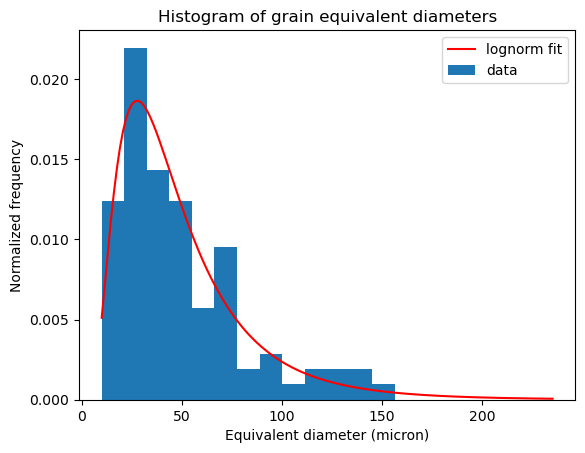

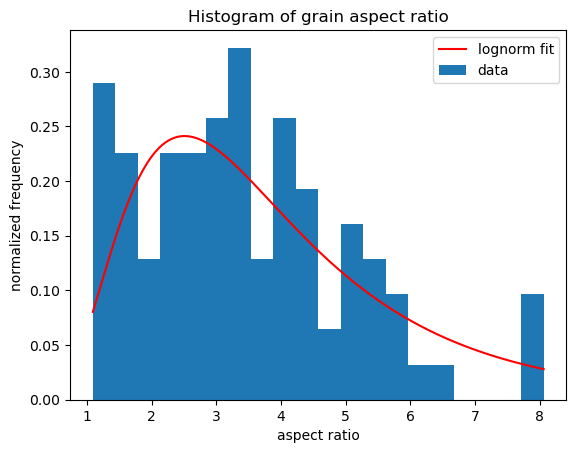

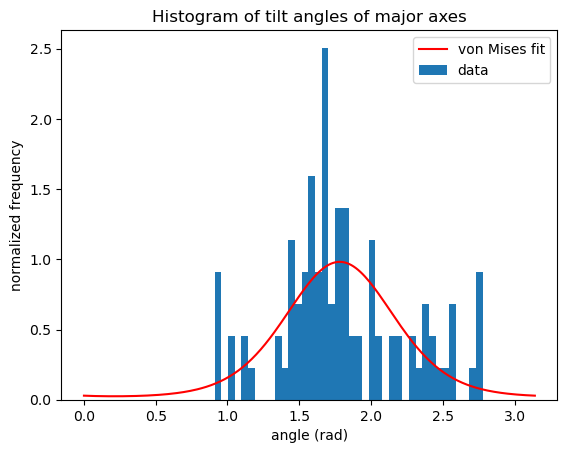

Analyzed microstructure of phase #0 (Iron fcc) with 94 grains.
Median values: equiv. diameter: 41.326 micron, aspect ratio: 3.441, tilt angle: 24.213°
Std. dev: equivalent diameter: 0.632 micron, aspect ratio: 0.563, tilt angle: 52.828°


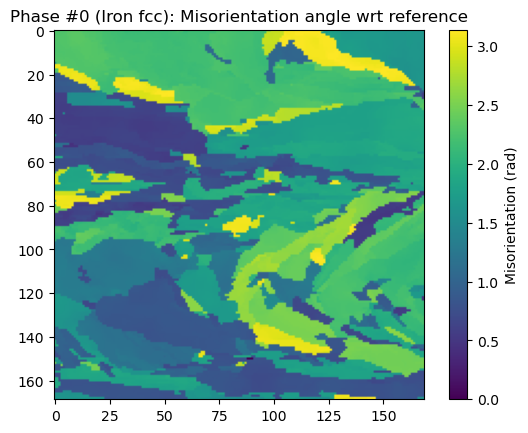

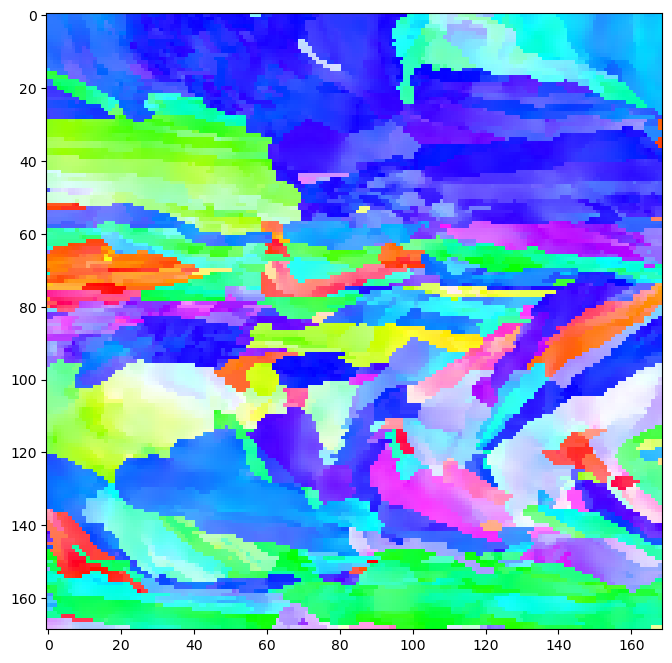

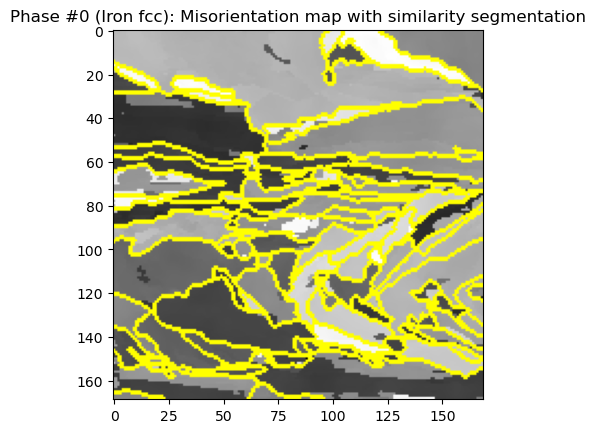

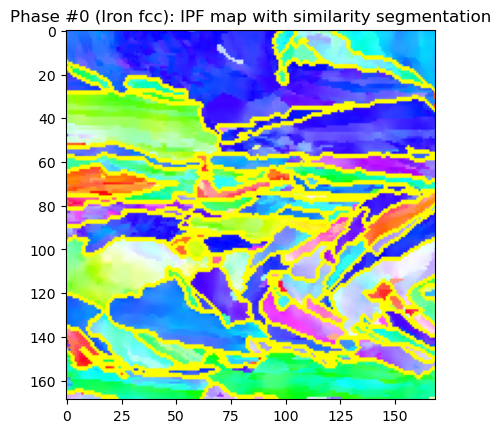

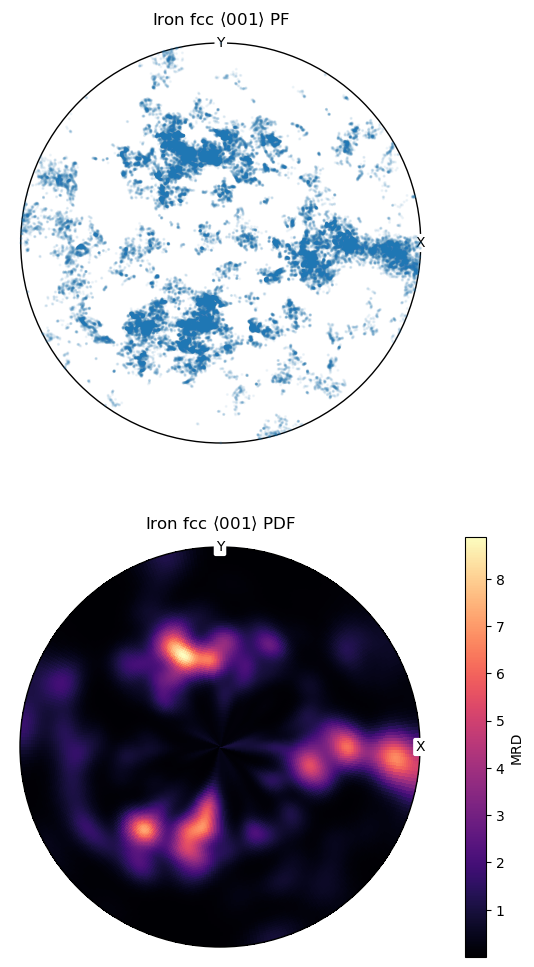

EBSD file loaded successfully!
  -> Current working directory: /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17
  -> EBSD file: ebsd_316L_500x500.ang



EBSD map loading is completed ........................................................
########################################################################################



########################################################################################
Extracting microstructure statistics .................................................






Microstructure statistics extracting is completed .................................
#####################################################################################



########################################################################################
Generating RVE .......................................................................



Creating an RVE based on user defined statistics
    Analyzed statistical data for phase iron_

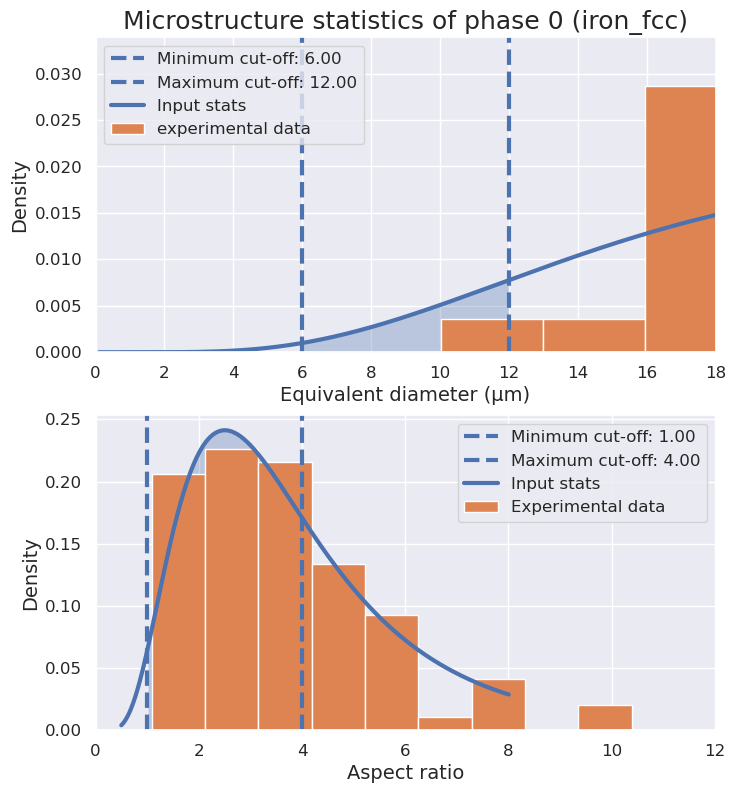

Starting particle simulation
    Creating particles from distribution statistics
    Total volume of generated ellipsoids: 8596.70645267471
    Particle packing by growth simulation
Volume of simulation box: 8000
Volume of unscaled particles: 8596.706452674713
Initial volume of scaled ellipsoids: 8.596706452674717, targeted final volume: 5587.859194238564
Volume increment per time step: 8.596706452674713


100%|███████████████████████████████████████████████████████████████████████████████| 1441/1441 [00:15<00:00, 90.66it/s]


Actual final volume of ellipsoids: 5580.33116479317
Completed particle packing
79 overlapping particles detected after packing
Kinetic energy of particles after packing: 40196.72510657449






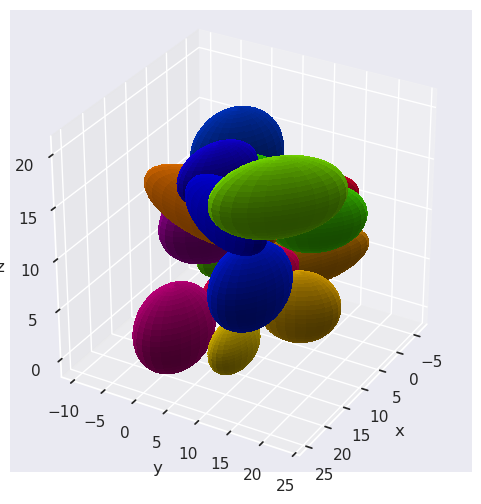

    Generating voxels inside RVE

Starting RVE voxelization
    Assigning voxels to grains


100%|██████████████████████████████████████████████████████████████████████████| 8000/8000 [00:00<00:00, 5404160.41it/s]


Completed RVE voxelization






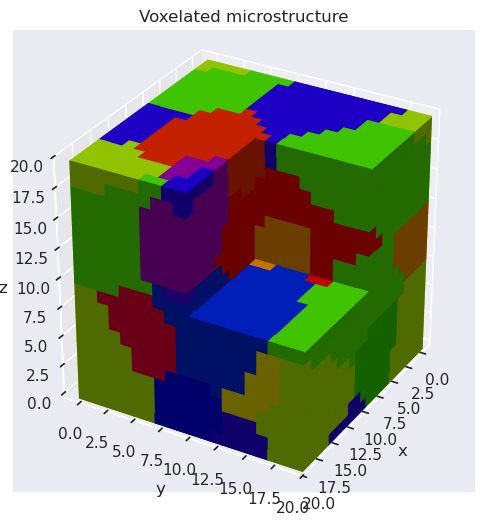


Generated Delaunay tesselation of grain vertices.
Assigning 717 tetrahedra to grains ...


717it [00:05, 129.97it/s] 


Finished generating polyhedral hulls for grains.
Total volume of RVE: 8000 um^3
Total volume of polyhedral grains: 7999.999999999999 um^3
Mean relative error of polyhedral vs. voxel volume of individual grains: 0.112
for mean volume of grains: 500.0 um^3.


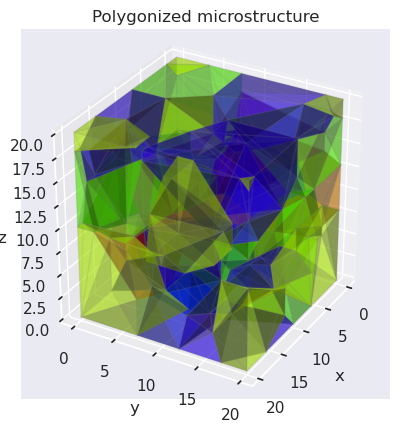

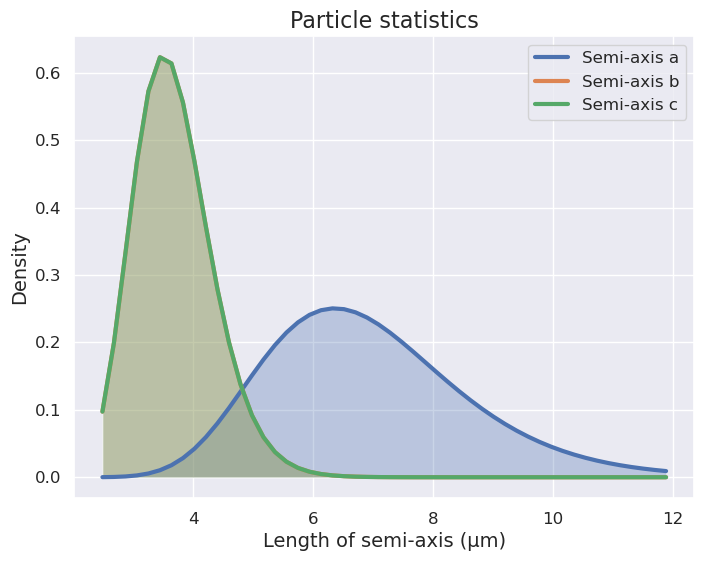

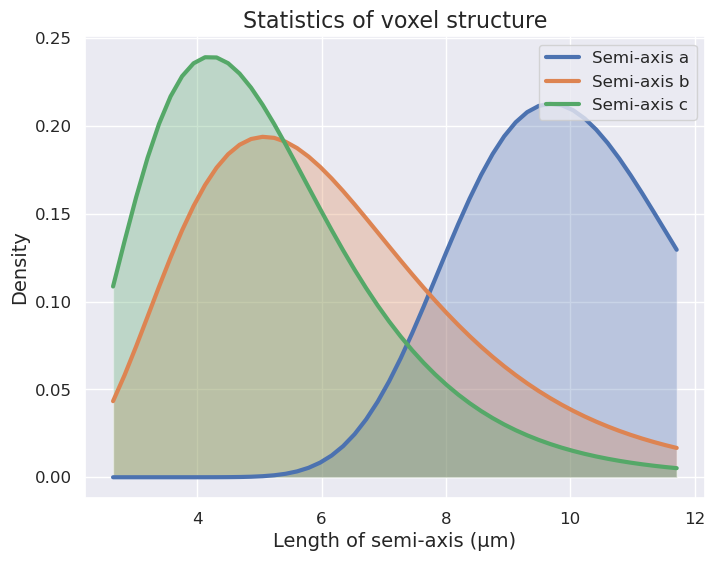

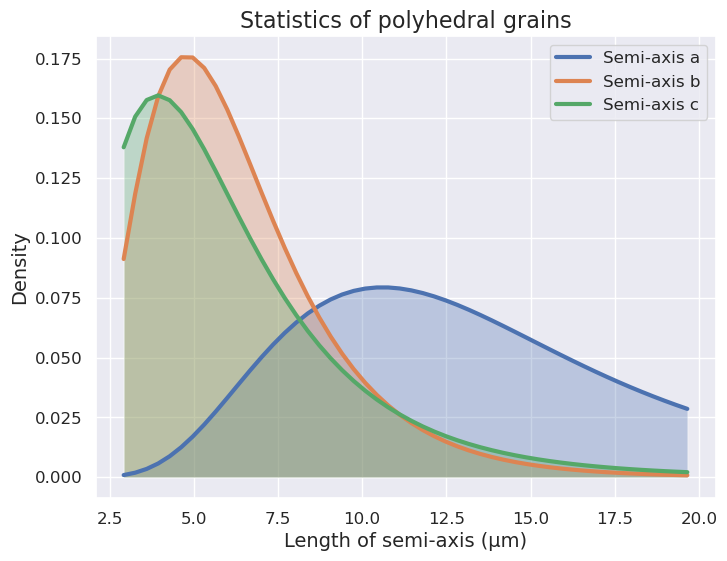


Statistical microstructure parameters of RVE
--------------------------------------------
Type	| a (µm) 	| b (µm) 	| c (µm) 	| std.dev	| rot.axis	| asp.ratio	| std.dev	| equ.dia. (µm)	| std.dev
Partcls	|  6.744	|  3.621	|  3.621	|  0.2003	|     0   	|  1.863	|  0.1992	|     9.529 	|  0.1321
Voxels	|  10.050	|  5.858	|  4.826	|  0.3121	|     0   	|  1.881	|  0.4173	|     13.120 	|  0.3256
Grains	|  12.776	|  5.765	|  5.300	|  0.4703	|     0   	|  2.309	|  0.3955	|     15.309 	|  0.2388


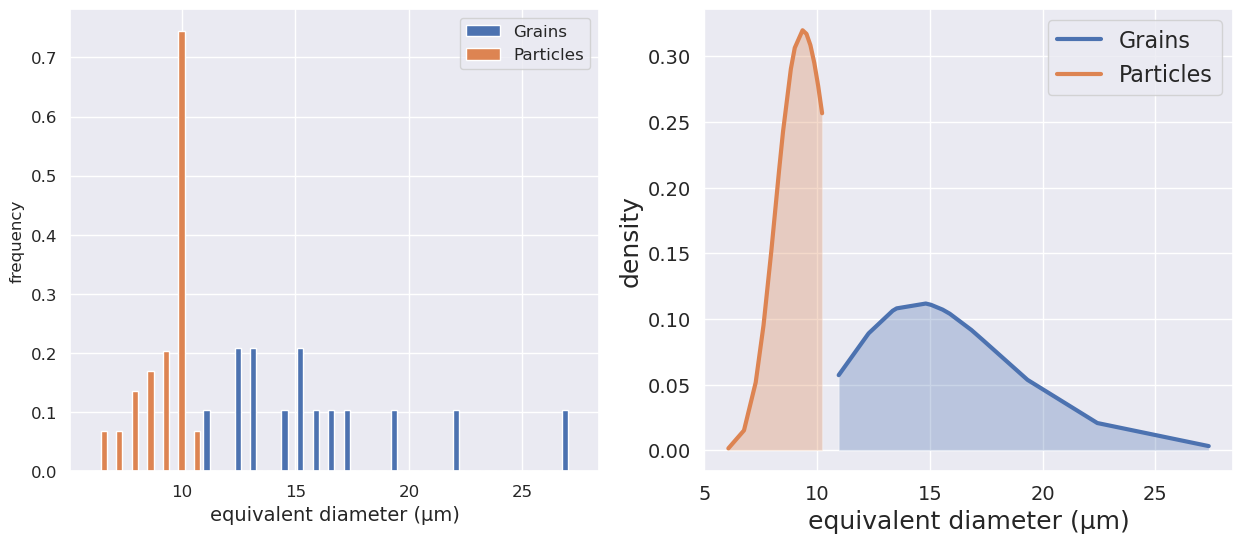

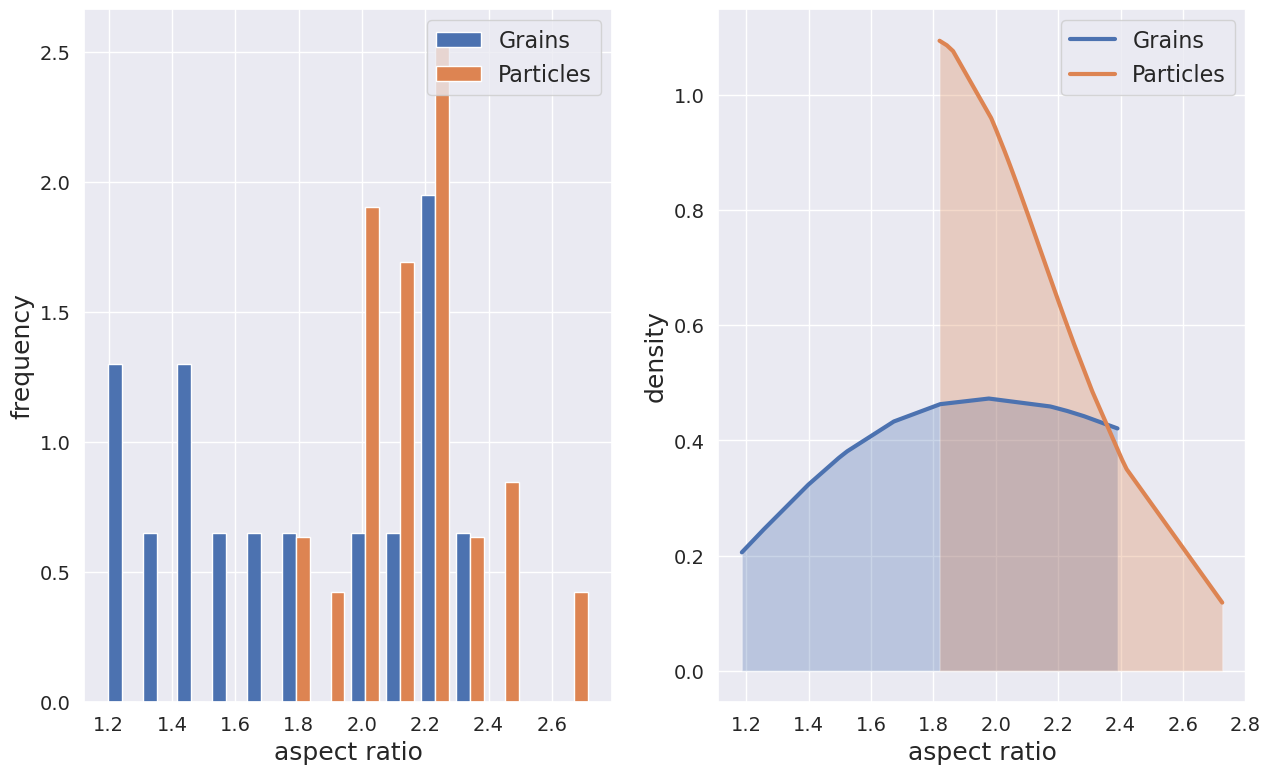

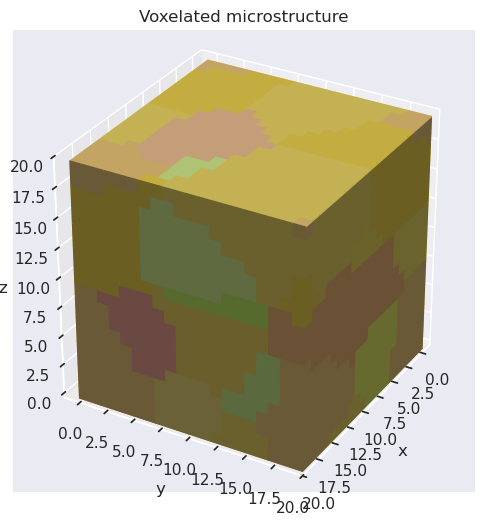




RVE generating is completed ........................................................
######################################################################################



########################################################################################
Exporting MiMeDO .......................................................................



Saved to: /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/results/fa7a100b.json
Folder key: fa7a100b_2e5b2_S_89e389d8



MiMeDO is exported .................................................................
######################################################################################



########################################################################################
Building grid/material/load from JSON ................................................



cells:  20 × 20 × 20
size:   1.9999999999999998e-05 × 1.9999999999999998e-05 × 1.9999999999999

/home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/nodes.py:1680: UserWarning: export_microstructure='voxels_with_grains' copies the initial grain dictionary into deformed snapshots. These grain-level fields are not updated by segmentation or grain-ID tracking. Use this mode only as an intermediate export. For physically meaningful grain-level evolution, post-process the result with grain segmentation and grain-ID tracking.
  updated_json = result.export_mimedo(


[OK] Homogenized mechanical response exported.
[OK] Top-level time was not exported.

[INFO] Streaming updated MiMeDat JSON to temporary file: /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/results/fa7a100b.json.tmp

[INFO] Exporting microstructure snapshots...
[INFO] Microstructure mode: voxels_with_grains
[INFO] Microstructure increments selected: 11
[INFO] Microstructure stride: 10
[INFO] Microstructure quantities: ['O', 'F', 'sigma', 'epsilon_V^0.0(F)']
[INFO]  increment_1 | t=1 | grid_size=[1.89515546e-05 1.90535762e-05 1.90040611e-05] | grid_spacing=[9.96960943e-07 1.00263390e-06 1.00000437e-06]
[INFO] Wrote microstructure snapshot increment_1 (1/11)
[INFO] increment_11 | t=11 | grid_size=[1.85260829e-05 1.97504555e-05 1.90511742e-05] | grid_spacing=[9.65839359e-07 1.03362471e-06 9.99968315e-07]
[INFO] Wrote microstructure snapshot increment_11 (2/11)
[INFO] Wrote microstructure snapshot increment_21 (3/11)


Segmenting snapshots:   0%|          | 0/12 [00:00<?, ?snapshot/s]


snap     status     mode         grid    BFS  final  merges   old     ARI
   0 undeformed ARI-only     20x20x20     14     14       0    16     nan
   1   deformed    write     20x20x20     14     14       0    16     nan
   2   deformed    write     20x20x20     14     14       0    16     nan
   3   deformed    write     20x20x20     27     14      13    16     nan
   4   deformed    write     20x20x20    129     14     115    16     nan
   5   deformed    write     20x20x20    386     14     372    16     nan
   6   deformed    write     20x20x20    764     17     747    16     nan
   7   deformed    write     20x20x20   1128     28    1100    16     nan
   8   deformed    write     20x20x20   1438     31    1407    16     nan
   9   deformed    write     20x20x20   1703     33    1670    16     nan
  10   deformed    write     20x20x20   1941     31    1910    16     nan
  11   deformed    write     20x20x20   2083     32    2051    16     nan

wrote /home/yousef/damaskWorkflows/e

Tracking grain IDs:   0%|          | 0/11 [00:00<?, ?it/s]



[OK] Update JSON, grain ids are updated




[OK] IPF colors are added


[INFO] Regridding is disabled.



Postprocessing is completed ....................................................................
##################################################################################################





In [6]:
wf.run();  # Run the workflow


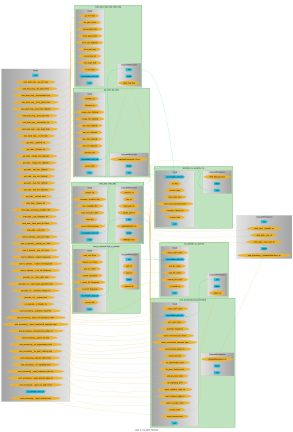

In [7]:
# Visualise the workflow as a node graph
wf.draw(size=(10, 6))


<class 'kanapy.core.api.Microstructure'>
Number of grains per phase: [16]
Texture source used: ODF


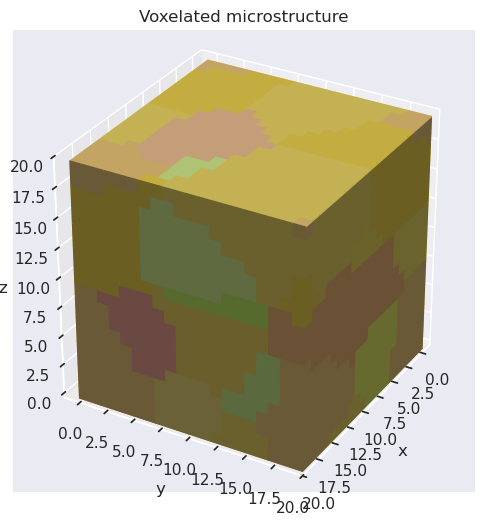


MiMeDO identifier: fa7a100b
Folder key:        fa7a100b_2e5b2_S_89e389d8
Saved to:          /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/results/fa7a100b.json
input_path:        /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/inputs
results_path:      /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/results

grid file:     /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/inputs/grid.vti
material file: /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/inputs/material.yaml
load file:     /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Version17/Keys/fa7a100b_2e5b2_S_89e389d8/inputs/load.yaml

DAMASK resu

In [8]:
# Inspect the generated RVE
rve = wf.generate_rve.outputs.RVE.value
print(type(rve))
print("Number of grains per phase:", rve.ngrains)

# Kanapy sets mesh.texture = "ODF" only when orientations were generated
# from a real EBSDmap object (the ori=wf.load_ebsd_map branch); it would
# read "Random" or "Unimodal" for the string-based textures instead. This
# is the direct check that the real-EBSD-orientation path actually ran.
print("Texture source used:", rve.mesh.texture)
assert rve.mesh.texture == "ODF", (
    "Expected orientations generated from the real EBSD map (texture='ODF'), "
    f"got {rve.mesh.texture!r} instead."
)

rve.plot_voxels(ori=True)

# Inspect the saved MiMeDO and its Keys/<key>/{inputs,results} folder
print()
print("MiMeDO identifier:", wf.write_data.outputs.identifier.value)
print("Folder key:       ", wf.write_data.outputs.key.value)
print("Saved to:         ", wf.write_data.outputs.pathtoMiMeDO.value)
print("input_path:       ", wf.write_data.outputs.input_path.value)
print("results_path:     ", wf.write_data.outputs.results_path.value)

# Inspect the three DAMASK input files load_to_damask just built
print()
print("grid file:    ", wf.load_to_damask.outputs.grid.value)
print("material file:", wf.load_to_damask.outputs.material.value)
print("load file:    ", wf.load_to_damask.outputs.load.value)

# Inspect the DAMASK HDF5 result produced by run_damask
print()
print("DAMASK result file:", wf.run_damask.outputs.results.value)

# Inspect the final, post-processed MiMeDO
print()
print("Final updated MiMeDO:", wf.post_processing.outputs.UpdatedDataObject.value)


## Investigate results

This is separate from the `wf` pipeline above -- run it after the workflow
finishes, to interactively explore the final MiMeDO (microstructure
snapshots, texture, mechanical response) using `mimedo_viewer`. Requires
`ipywidgets`.

`voxel_graph.py` (used lazily by the viewer's weighted-misorientation
graph view) is not part of segmentation -- `segment_microstructure.py` has
its own, separate graph-building code and never imports it. It lives in
`functions/` next to the viewer, so the view works
from any working directory; this case folder holds only case-specific
things.

In [9]:
from functions.mimedo_viewer import mimedat_viewer

mimedat_viewer(wf.post_processing.outputs.UpdatedDataObject.value)


Output()